# Audit of the experiment folders

The depth study rests on things that are easy to assume and cheap to check. This notebook checks them against the
artefacts in `experiments/` and reports per run. As in the performance notebook, the benchmark (WN18RRv1) and the ADNI
connectome runs (data_v10, seed_81) are shown separately wherever there is a figure.

| Section | Question | Evidence |
|---|---|---|
| 1 | Is the depth in `config.yaml` the depth of the saved model? | `model.pt` via `torch.load` |
| 2 | Do the trained weights satisfy the monotonicity constraints? | parameter tensors |
| 3 | How did the weights develop during training? | `checkpoints/*.pt` |
| 4 | Is the AUPRC in the metrics file right? | recompute with the repo's `compute_metrics` |
| 5 | What does the bias alone derive at the derivation threshold? | last-layer bias |
| 6 | Does the model separate the classes at all? | example scores |
| 7 | How do the validation and test splits differ? | graph and example files |
| 8 | Which facts were explained and are the rules well formed? | `explanations.txt` |

Models are loaded with `torch.load`, which needs the repo on `sys.path` so that the `GNN` class can be found.

In [1]:
import sys, re, glob, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

REPO = Path.cwd().parent          # analysis_v2/ -> MGNN_v2/
sys.path.insert(0, str(REPO))
EXP = REPO / "experiments"
DATA = REPO / "data" / "link_prediction"
os.makedirs("figures", exist_ok=True)

TYPE = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"
COL = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}   # one colour per depth, used everywhere
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# one row per experiment folder
rows = []
for f in sorted(EXP.iterdir()):
    if not (f / "config.yaml").exists():
        continue
    cfg = yaml.safe_load(open(f / "config.yaml"))
    cfg = {k.strip(): v for k, v in cfg.items()}           # 'num_layers ' has a stray space in some configs
    dataset = Path(cfg["data_dir"]).name
    ckpts = [int(re.search(r"Epoch(\d+)", p).group(1)) for p in glob.glob(str(f / "checkpoints" / "*.pt"))]
    rows.append({"run": f.name, "dataset": dataset, "L": int(cfg["num_layers"]), "encoding": cfg["encoding_scheme"],
                 "aggregations": ",".join(cfg["aggregations"]), "theta_der": float(cfg["derivation_threshold"]),
                 "last_ckpt_epoch": max(ckpts) if ckpts else None, "folder": f, "data_dir": DATA / dataset})
runs = pd.DataFrame(rows).sort_values(["dataset", "L"]).reset_index(drop=True)

# the two families of datasets are analysed separately: a KG-completion benchmark with a binary target,
# and the two ADNI connectome datasets with the unary target positive(patient)
GROUPS = {"WN18RRv1 (benchmark)": ["WN18RRv1"],
          "ADNI connectomes": [d for d in ["data_v10", "seed_81"] if d in set(runs.dataset)]}
runs.drop(columns=["folder", "data_dir"])


,run,dataset,L,encoding,aggregations,theta_der,last_ckpt_epoch
0,WN18RRv1_L1,WN18RRv1,1,iclr22,max,1.000000e-09,17000
1,WN18RRv1_L2,WN18RRv1,2,iclr22,"max,max",1.000000e-09,6000
2,WN18RRv1_L3,WN18RRv1,3,iclr22,"max,max,max",1.000000e-09,5000
3,data_v10_L1,data_v10,1,canonical,max,1.000000e-09,8000
4,data_v10_L2,data_v10,2,canonical,"max,max",1.000000e-09,0
5,data_v10_L3,data_v10,3,canonical,"max,max,max",1.000000e-09,16000
6,seed_81_L1,seed_81,1,canonical,max,1.000000e-09,7000
7,seed_81_L2,seed_81,2,canonical,"max,max",1.000000e-09,9000
8,seed_81_L3,seed_81,3,canonical,"max,max,max",1.000000e-09,0


In [2]:
def read_metrics(path):
    """test_metrics.txt / valid_metrics.txt -> (per-threshold DataFrame, AUPRC printed in the file)"""
    df = pd.read_csv(path, sep="\t", nrows=sum(1 for l in open(path) if not l.startswith("Area")) - 1)
    df.columns = ["threshold", "precision", "recall", "accuracy", "f1"]
    area = [l for l in open(path) if l.startswith("Area")]
    auprc = float(area[0].split(":")[1]) if area else None   # test_at_valid_threshold.txt has no AUPRC line
    return df, auprc

def read_tsv(path, cols):
    return pd.read_csv(path, sep="\t", header=None, names=cols, dtype=str, quoting=3, keep_default_na=False)

def example_scores(run):
    """scores the model gave to the test positives / negatives (0 if the fact was not derived at all)"""
    pred = read_tsv(run.folder / "predicted_triples_scored.tsv", ["s", "p", "o", "score"])
    pred["score"] = pred["score"].astype(float)
    lookup = dict(zip(zip(pred.s, pred.p, pred.o), pred.score))
    pos = read_tsv(run.data_dir / "test_pos.tsv", ["s", "p", "o"])
    neg = read_tsv(run.data_dir / "test_neg.tsv", ["s", "p", "o"])
    ps = np.array([lookup.get(t, 0.0) for t in zip(pos.s, pos.p, pos.o)])
    ns = np.array([lookup.get(t, 0.0) for t in zip(neg.s, neg.p, neg.o)])
    return ps, ns, pred

def slug(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

import torch

def load_params(path):
    """{parameter name: numpy array} for a saved model"""
    m = torch.load(path, weights_only=False, map_location="cpu")
    return m, {n: p.detach().cpu().numpy() for n, p in m.named_parameters()}

def layer_mats(params, L):
    """A_l (out x in), B_l (colours x out x in) and bias b_l for l = 1..L"""
    return {l: {"A": params[f"lin_selfs.{l-1}.weight"], "B": params[f"convs.{l-1}.weights"], "b": params[f"lin_selfs.{l-1}.bias"]}
            for l in range(1, L + 1)}

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def target_position(r):
    """index of the target unary predicate in the model output ('positive' for ADNI, the explained head for WN18RRv1)"""
    unary = {int(i): p for k, i, p in (l.split("\t") for l in open(r.folder / "internal_encoder.tsv").read().splitlines()) if k == "UNARY"}
    if r.encoding == "iclr22":
        rule = open(r.folder / "explanations.txt").read().splitlines()[1]
        target = "unary-for-" + re.search(r"<([^>]+)>", rule).group(1)
    else:
        target = "positive"
    return {v: k for k, v in unary.items()}[target], target


## 1. Depth: config vs saved model

**Why.** The model class originally had the number of layers hard-coded at two, so a "three-layer" configuration
silently trained a two-layer model. Now that depth is a parameter, the three places it is recorded — the config, the
`num_layers` attribute on the pickled module, and the number of colour-matrix tensors actually present — must agree.
Dimensions should read δ, 2δ, …, δ.

In [3]:
models, rows = {}, []
for _, r in runs.iterrows():
    m, params = load_params(r.folder / "model.pt")
    n_conv = sum(n.startswith("convs.") for n in params)
    models[r.run] = (m, params)
    rows.append({"run": r.run, "L config": r.L, "L model attr": m.num_layers, "conv layers in file": n_conv,
                 "dimensions": m.dimensions, "aggregations": getattr(m, "agg_functions", None),
                 "n params": sum(p.size for p in params.values()), "ok": r.L == m.num_layers == n_conv})
pd.DataFrame(rows)


,run,L config,L model attr,conv layers in file,dimensions,aggregations,n params,ok
0,WN18RRv1_L1,1,1,1,"[9, 9]",[max],414,True
1,WN18RRv1_L2,2,2,2,"[9, 18, 9]","[max, max]",1647,True
2,WN18RRv1_L3,3,3,3,"[9, 18, 18, 9]","[max, max, max]",3285,True
3,data_v10_L1,1,1,1,"[95, 95]",[max],117420,True
4,data_v10_L2,2,2,2,"[95, 190, 95]","[max, max]",469585,True
5,data_v10_L3,3,3,3,"[95, 190, 190, 95]","[max, max, max]",939075,True
6,seed_81_L1,1,1,1,"[117, 117]",[max],164385,True
7,seed_81_L2,2,2,2,"[117, 234, 117]","[max, max]",657423,True
8,seed_81_L3,3,3,3,"[117, 234, 234, 117]","[max, max, max]",1314729,True


**Result.** All nine runs agree on all three counts and the hidden widths are 2δ (δ = 9 for WN18RRv1, 95 for
data_v10, 117 for seed_81). The parameter count grows from a few hundred (WN18RRv1, L=1) to over a million
(seed_81, L=3), which matters when reading the training curves in Section 3: the ADNI models are trained on far
fewer positive examples than they have parameters.

## 2. Monotonicity constraints and sparsity

**Why.** The soundness guarantee for the extracted rules needs every entry of A and B to be ≥ 0 (the bias may be
negative). Projection after each optimiser step should enforce this, but it is worth confirming on the saved
weights. The zero fraction is the sparsity the rule extraction relies on to keep Γ small; `max` gives the scale of the
largest single weight, which matters for the bias-floor argument in Section 5.

all A and B matrices non-negative: True


,run,matrix,shape,min,max,zero fraction,non-negative
0,WN18RRv1_L1,A1,"(9, 9)",0.0000,6.2391,0.9630,True
1,WN18RRv1_L1,B1,"(4, 9, 9)",0.0000,13.9116,0.9753,True
2,WN18RRv1_L1,b1,"(9,)",-7.5573,0.8687,NaN,None
3,WN18RRv1_L2,A1,"(18, 9)",0.0000,3.8615,0.8519,True
4,WN18RRv1_L2,B1,"(4, 18, 9)",0.0000,2.3603,0.8889,True
5,WN18RRv1_L2,b1,"(18,)",-2.5432,0.7275,NaN,None
6,WN18RRv1_L2,A2,"(9, 18)",0.0000,2.4758,0.9136,True
7,WN18RRv1_L2,B2,"(4, 9, 18)",0.0000,9.1307,0.9213,True
8,WN18RRv1_L2,b2,"(9,)",-16.7283,-0.7610,NaN,None
9,WN18RRv1_L3,A1,"(18, 9)",0.0000,2.5487,0.8827,True


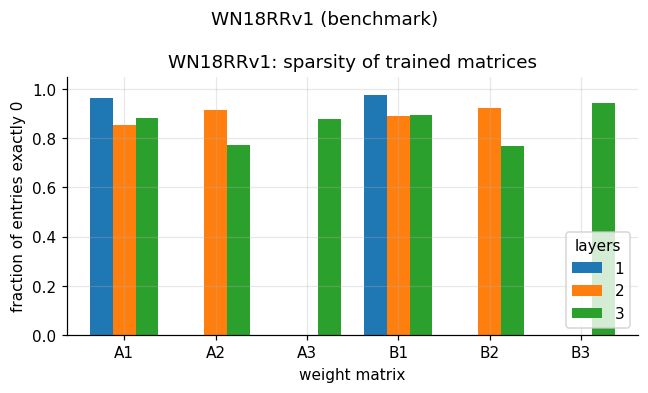

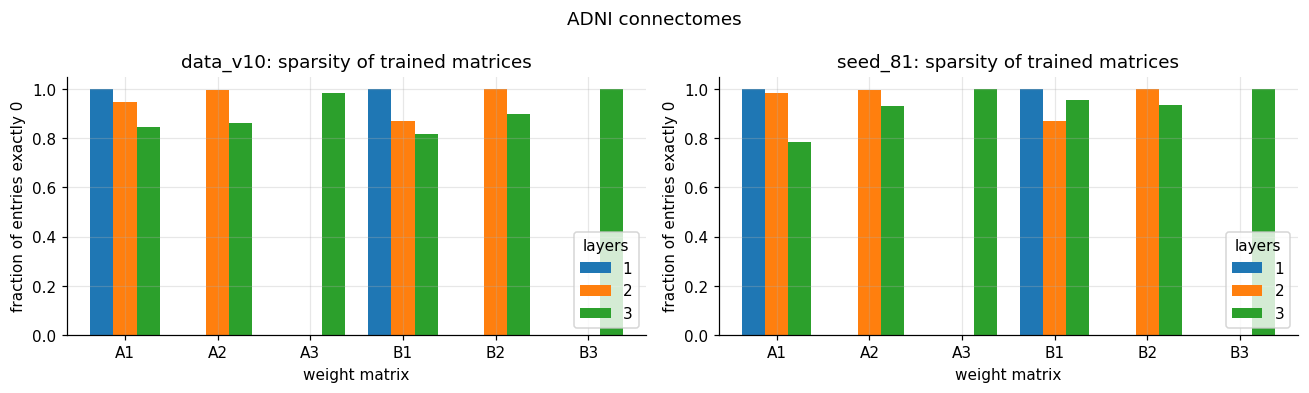

In [4]:
rows = []
for _, r in runs.iterrows():
    m, params = models[r.run]
    for l, mats in layer_mats(params, m.num_layers).items():
        for name in ["A", "B"]:
            w = mats[name]
            rows.append({"run": r.run, "dataset": r.dataset, "L": r.L, "matrix": f"{name}{l}", "shape": w.shape, "min": w.min(),
                         "max": w.max(), "zero fraction": (w == 0).mean(), "non-negative": bool(w.min() >= 0)})
        rows.append({"run": r.run, "dataset": r.dataset, "L": r.L, "matrix": f"b{l}", "shape": mats["b"].shape, "min": mats["b"].min(),
                     "max": mats["b"].max(), "zero fraction": np.nan, "non-negative": None})
weights = pd.DataFrame(rows)
print("all A and B matrices non-negative:", weights["non-negative"].dropna().all())
display(weights.drop(columns=["dataset", "L"]).round(4))

def sparsity_plot(name, dsets):
    fig, axes = plt.subplots(1, len(dsets), figsize=(6 * len(dsets), 3.6), squeeze=False)
    for ax, ds in zip(axes[0], dsets):
        sub = weights[(weights.dataset == ds) & weights.matrix.str.startswith(("A", "B"))]
        piv = sub.pivot(index="matrix", columns="L", values="zero fraction")
        piv.plot.bar(ax=ax, rot=0, width=0.75, color=[COL[L] for L in piv.columns])
        ax.set(ylim=(0, 1.05), xlabel="weight matrix", ylabel="fraction of entries exactly 0", title=f"{ds}: sparsity of trained matrices")
        ax.legend(title="layers", loc="lower right")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/sparsity_{slug(name)}.png"); plt.show()

for name, dsets in GROUPS.items():
    sparsity_plot(name, dsets)


**What it shows.** No violations: every A and B has minimum exactly 0, so the projection worked and the extracted
rules are sound with respect to the saved models. Sparsity is high everywhere (77–100% zeros), which is what the
weight-decay-plus-projection mechanism is meant to produce. Two details stand out. On WN18RRv1 the last-layer biases
are strongly negative (down to −16.7 at L=2), while the colour matrices contain weights up to 9–14 — single inputs
that can move a pre-activation by more than the −10 shift. On the ADNI runs the self-matrix A₁ is *entirely* zero for both L=1 models
(data_v10 and seed_81), and several deeper matrices are above 99.9% zero: whole blocks of the network contribute
nothing, which is consistent with the models having found the "every patient is positive" solution and stopped.

**Takeaway.** The monotonicity constraints hold, so the guarantees apply. The sparsity patterns are the first hint
that the ADNI models converged to a degenerate solution rather than a rule about the connectome.

## 3. Weights over the checkpoints

**Why.** The training loop does not write its loss to disk, but it saves the model every 1,000 epochs. Reading those
gives the development of sparsity, of the largest weight, and of the last-layer bias at the target position, which
together show how the model arrived at its final state and when it stopped. The last point of each line is the last
checkpoint before early stopping (patience 50 on the training loss); a run whose only checkpoint is epoch 0 stopped in
under 1,000 epochs.

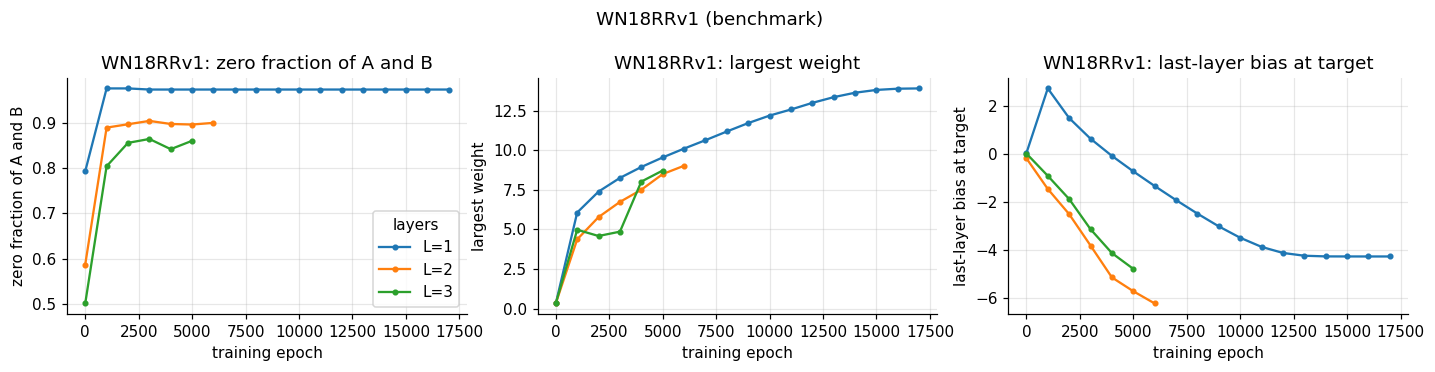

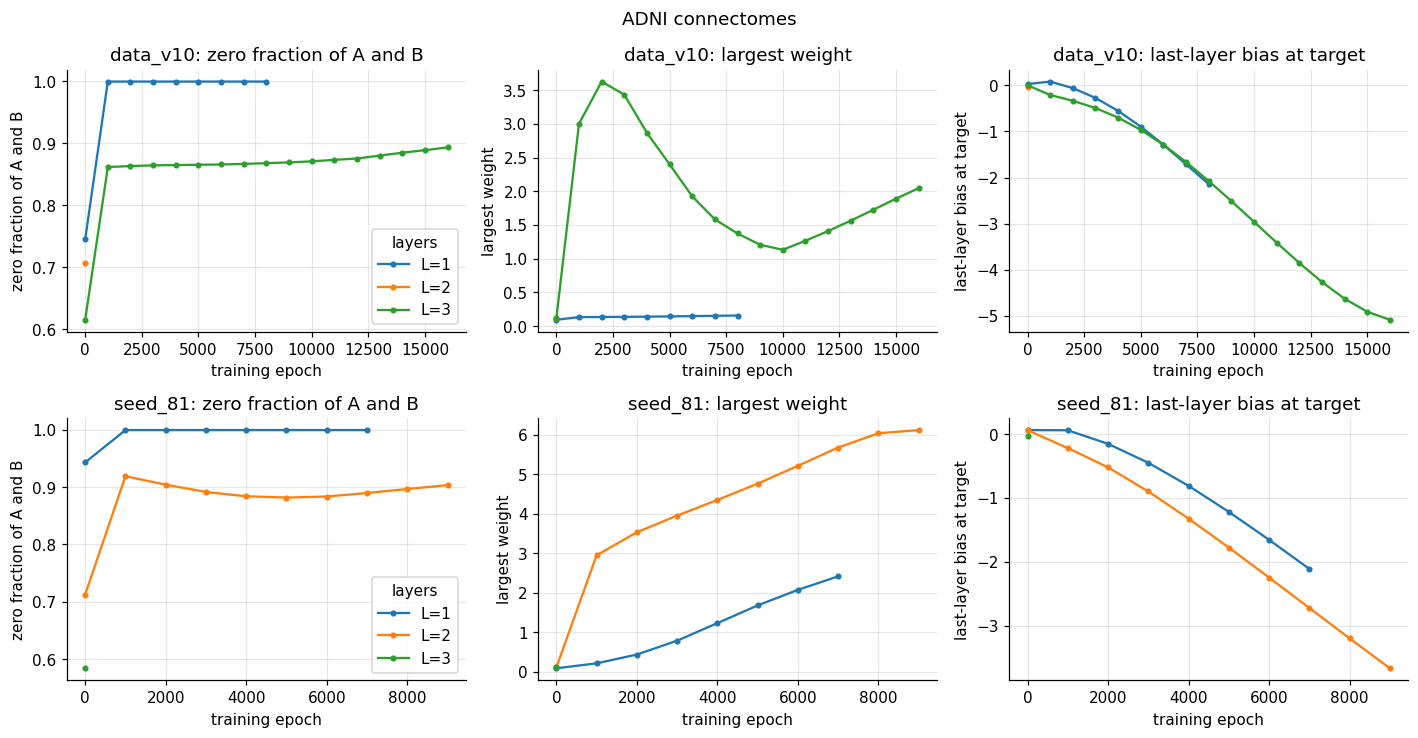

In [5]:
traj = []
for _, r in runs.iterrows():
    pos, target = target_position(r)
    for ck in sorted(glob.glob(str(r.folder / "checkpoints" / "*.pt")), key=lambda p: int(re.search(r"Epoch(\d+)", p).group(1))):
        epoch = int(re.search(r"Epoch(\d+)", ck).group(1))
        m, params = load_params(ck)
        AB = np.concatenate([v.ravel() for n, v in params.items() if "bias" not in n])
        b_last = params[f"lin_selfs.{m.num_layers-1}.bias"]
        traj.append({"dataset": r.dataset, "L": r.L, "epoch": epoch, "zero fraction of A and B": (AB == 0).mean(),
                     "largest weight": AB.max(), "last-layer bias at target": b_last[pos]})
traj = pd.DataFrame(traj)

def checkpoint_plot(name, dsets):
    cols = ["zero fraction of A and B", "largest weight", "last-layer bias at target"]
    fig, axes = plt.subplots(len(dsets), 3, figsize=(13, 3.4 * len(dsets)), squeeze=False)
    for i, ds in enumerate(dsets):
        for j, col in enumerate(cols):
            ax = axes[i, j]
            for L, g in traj[traj.dataset == ds].groupby("L"):
                ax.plot(g.epoch, g[col], "o-", ms=3, color=COL[L], label=f"L={L}")
            ax.set(title=f"{ds}: {col}", xlabel="training epoch", ylabel=col)
            if j == 0: ax.legend(title="layers")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/checkpoints_{slug(name)}.png"); plt.show()

for name, dsets in GROUPS.items():
    checkpoint_plot(name, dsets)


**What it shows.** *WN18RRv1:* sparsity jumps to 80–95% within the first 1,000 epochs and then barely moves, the
largest weight keeps growing slowly, and the target bias drifts steadily negative — the model is sharpening a
solution it found early. L=1 trained three times longer than L=2/3 before the patience ran out. *ADNI:* the same
early jump in sparsity, but the runs are very uneven — data_v10 L=2 and seed_81 L=3 stopped before the first
checkpoint (their curves are a single point at epoch 0), while data_v10 L=3 ran to 16,000. The bias at `positive`
drifts negative on every run, which is the network pushing the region nodes' `positive` score down, not learning
anything about patients.

**Takeaway.** Early stopping on training loss with a patience of 50 gives training lengths that vary by more than
an order of magnitude between otherwise identical configurations. That is a confound for any depth comparison and
an argument for either a longer patience or validation-based checkpoint selection.

## 4. Metrics file vs recomputed

**Why.** `compute_metrics.py` used to compute the AUPRC with `recall(tp, fp)` instead of `recall(tp, fn)`, which
made the "AUPRC" the area of precision against itself. The scored predictions file is exactly what
`compute_metrics` was given, so re-running the fixed function on it and comparing the AUPRC line tells whether a
metrics file was written before or after the fix.

In [6]:
from src.run.compute_metrics import compute_metrics
import tempfile

rows = []
for _, r in runs.iterrows():
    pred = read_tsv(r.folder / "predicted_triples_scored.tsv", ["s", "p", "o", "score"])
    predictions = {(s, p, o): float(sc) for s, p, o, sc in zip(pred.s, pred.p, pred.o, pred.score)}
    tmp = Path(tempfile.mkdtemp()) / "test_metrics.txt"
    compute_metrics(predictions, r.data_dir / "test_pos.tsv", r.data_dir / "test_neg.tsv", tmp)
    _, auprc_file = read_metrics(r.folder / "test_metrics.txt")
    _, auprc_new = read_metrics(tmp)
    rows.append({"run": r.run, "AUPRC in file": auprc_file, "AUPRC recomputed": auprc_new,
                 "status": "ok" if abs(auprc_file - auprc_new) < 1e-6 else "MISMATCH - file predates the fix"})
pd.DataFrame(rows)


,run,AUPRC in file,AUPRC recomputed,status
0,WN18RRv1_L1,0.938734,0.938734,ok
1,WN18RRv1_L2,0.938327,0.938327,ok
2,WN18RRv1_L3,0.938930,0.938930,ok
3,data_v10_L1,0.241935,0.241935,ok
4,data_v10_L2,0.241935,0.241935,ok
5,data_v10_L3,0.241935,0.241935,ok
6,seed_81_L1,0.250000,0.250000,ok
7,seed_81_L2,0.250000,0.250000,ok
8,seed_81_L3,0.250000,0.250000,ok


**Result.** All nine files match the corrected calculation, so every AUPRC quoted from them is genuine. One
convention worth knowing: the threshold sweep is rounded to 10 decimals, so its last entry is exactly 1.0 and a score
of exactly 1.0 does *not* count as derived there. A model that gives every patient the score 1.0 therefore ends its
PR curve at (0, 0) and gets an AUPRC of half the positive share (0.24 on data_v10, 0.25 on seed_81) rather than the
positive share itself. That is why AP is reported alongside AUPRC in the performance notebook.

## 5. What the bias alone derives

**Why.** With non-negative weights, the smallest value the last layer can output at position *i* is
sigmoid(b_i − 10), reached when every input feature and every neighbour is zero. If that floor is already above the
derivation threshold, the predicate at position *i* is "derived" for every constant on every dataset, including an
empty one. The bars show the floor for each output position (the target predicate in purple) against the derivation
threshold; the table also compares the number of derived facts with nodes × δ, the total number of cells.

,run,delta,positions above threshold from bias alone,floor at target,derivation threshold,facts derived,nodes x delta
0,WN18RRv1_L1,9,9,6.271337e-07,1.000000e-09,21582,NaN
1,WN18RRv1_L2,9,8,6.889142e-08,1.000000e-09,20565,NaN
2,WN18RRv1_L3,9,9,3.575132e-07,1.000000e-09,21582,NaN
3,data_v10_L1,95,95,4.388138e-06,1.000000e-09,250325,250325.0
4,data_v10_L2,95,95,4.682178e-05,1.000000e-09,250325,250325.0
5,data_v10_L3,95,95,2.701195e-07,1.000000e-09,250325,250325.0
6,seed_81_L1,117,117,4.745702e-06,1.000000e-09,272493,272493.0
7,seed_81_L2,117,117,1.213204e-06,1.000000e-09,272493,272493.0
8,seed_81_L3,117,117,5.425903e-05,1.000000e-09,272493,272493.0


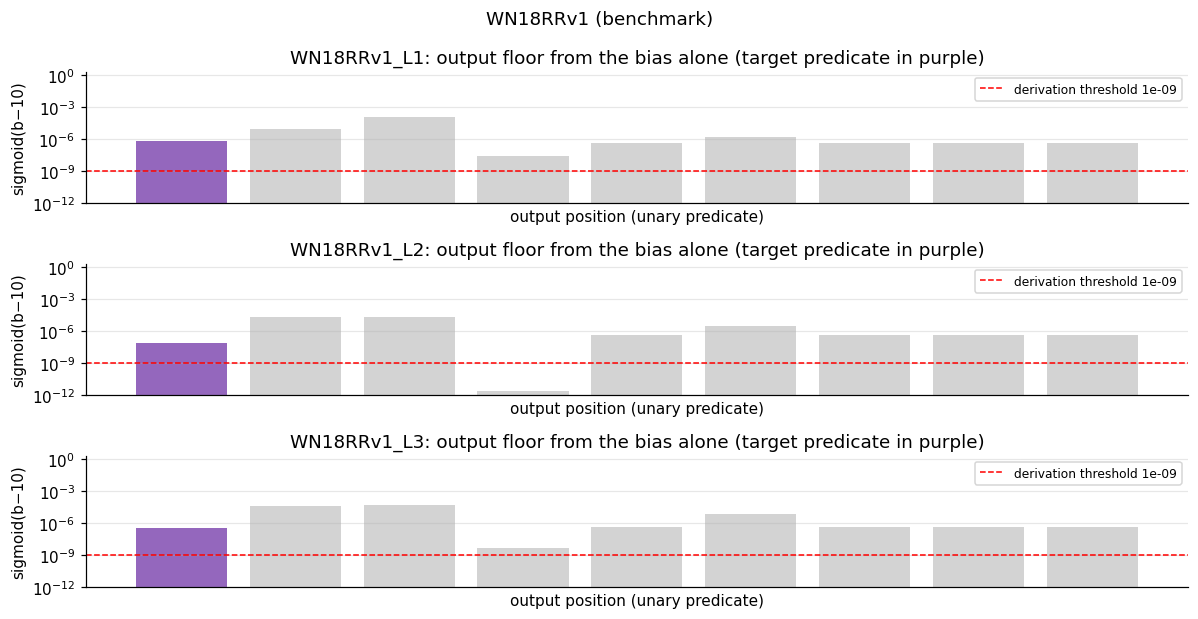

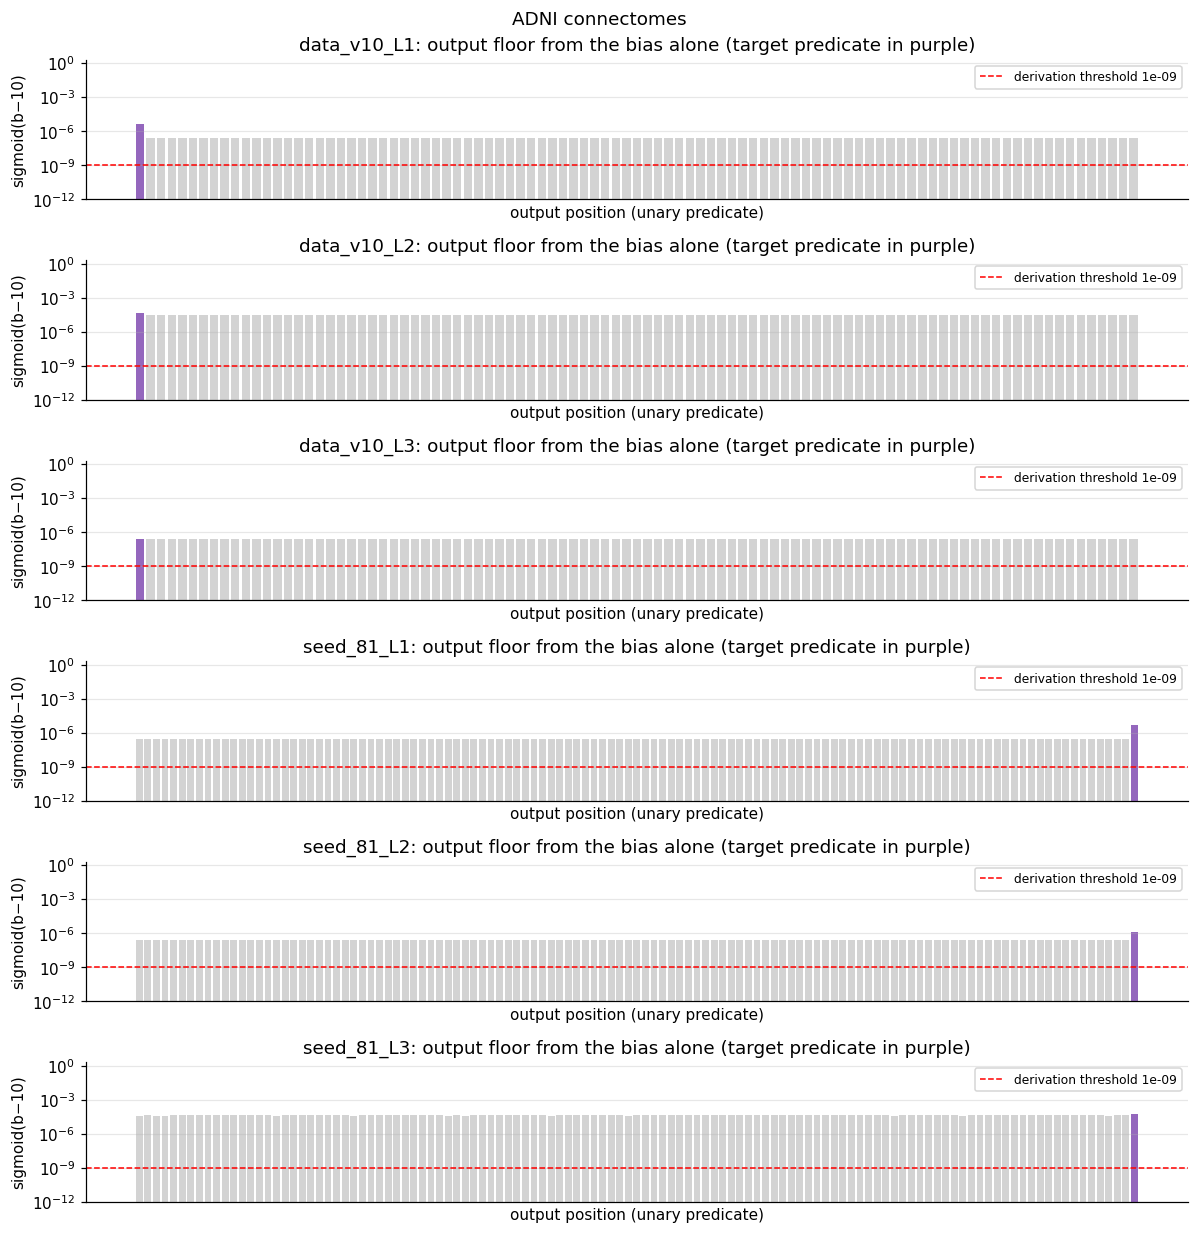

In [7]:
rows, floors = [], {}
for _, r in runs.iterrows():
    m, params = models[r.run]
    floor = sigmoid(params[f"lin_selfs.{m.num_layers-1}.bias"] - 10)
    pos, target = target_position(r)
    floors[r.run] = (floor, pos)
    n_pred = sum(1 for _ in open(r.folder / "predicted_triples_scored.tsv"))
    g = read_tsv(r.data_dir / "test_graph.tsv", ["s", "p", "o"])
    n_nodes = len(set(g.s) | set(g[g.p != TYPE].o)) if r.encoding == "canonical" else None
    rows.append({"run": r.run, "delta": len(floor), "positions above threshold from bias alone": int((floor > r.theta_der).sum()),
                 "floor at target": floor[pos], "derivation threshold": r.theta_der, "facts derived": n_pred,
                 "nodes x delta": n_nodes * len(floor) if n_nodes else None})
display(pd.DataFrame(rows))

def bias_floor_plot(name, dsets):
    sub = runs[runs.dataset.isin(dsets)]
    fig, axes = plt.subplots(len(sub), 1, figsize=(11, 1.9 * len(sub)), squeeze=False)
    for ax, (_, r) in zip(axes[:, 0], sub.iterrows()):
        floor, pos = floors[r.run]
        ax.bar(range(len(floor)), floor, color=["tab:purple" if i == pos else "lightgrey" for i in range(len(floor))])
        ax.axhline(r.theta_der, color="red", ls="--", lw=1, label=f"derivation threshold {r.theta_der:g}")
        ax.set_yscale("log")
        ax.set(ylim=(1e-12, 2), xlabel="output position (unary predicate)", ylabel="sigmoid(b−10)",
               title=f"{r.run}: output floor from the bias alone (target predicate in purple)", xticks=[])
        ax.legend(loc="upper right", fontsize=8)
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/bias_floor_{slug(name)}.png"); plt.show()

for name, dsets in GROUPS.items():
    bias_floor_plot(name, dsets)


**What it shows.** All but one bar across the nine runs is above the red line (the exception is a single position on
WN18RRv1 L=2): with a derivation threshold of 10⁻⁹, essentially every position of every model is derived from the bias
alone, the floors sitting between 10⁻⁸ and 10⁻⁴. On the ADNI
runs the consequence is exact — the number of derived facts equals nodes × δ (250,325 on data_v10, 272,493 on seed_81):
every node is assigned every predicate. On WN18RRv1 the 21,000-odd derived facts are similarly the whole candidate
set of pair-term nodes.

**Takeaway.** At 10⁻⁹ "derived" does not mean anything: the model output has to be thresholded above the bias
floor (10⁻⁴ or so on these runs) before the set of derived facts, and therefore the choice of which fact to explain,
carries information. The metric sweeps are unaffected, since they scan all thresholds, but `predicted_triples.tsv`
and the explanations are.

## 6. Is the classifier doing anything?

**Why.** AUROC and the score strips in the performance notebook already answer this; here the same check is kept
as an audit line per run so the summary table can carry it, with the ADNI region nodes added for context.

In [8]:
from sklearn.metrics import roc_auc_score
rows = []
for _, r in runs.iterrows():
    ps, ns, pred = example_scores(r)
    auroc = roc_auc_score(np.r_[np.ones(len(ps)), np.zeros(len(ns))], np.r_[ps, ns])
    row = {"run": r.run, "AUROC": round(auroc, 3), "distinct scores (pos)": len(set(ps)), "distinct scores (neg)": len(set(ns)),
           "median score pos": np.median(ps), "median score neg": np.median(ns)}
    if r.encoding == "canonical":
        examples = set(read_tsv(r.data_dir / "test_pos.tsv", ["s", "p", "o"]).s) | set(read_tsv(r.data_dir / "test_neg.tsv", ["s", "p", "o"]).s)
        row["median score of region nodes"] = pred[(pred.o == "positive") & (~pred.s.isin(examples))].score.median()
    row["verdict"] = "constant classifier" if abs(auroc - 0.5) < 0.02 else "separates the classes"
    rows.append(row)
separation = pd.DataFrame(rows)
separation


,run,AUROC,distinct scores (pos),distinct scores (neg),median score pos,median score neg,verdict,median score of region nodes
0,WN18RRv1_L1,0.925,6,14,0.608924,6.271337e-07,separates the classes,NaN
1,WN18RRv1_L2,0.926,23,41,0.582828,4.305327e-07,separates the classes,NaN
2,WN18RRv1_L3,0.924,31,49,0.578679,4.334904e-07,separates the classes,NaN
3,data_v10_L1,0.500,1,1,0.909704,9.097043e-01,constant classifier,4.388138e-06
4,data_v10_L2,0.500,1,1,1.000000,1.000000e+00,constant classifier,1.140467e-04
5,data_v10_L3,0.500,1,1,1.000000,1.000000e+00,constant classifier,2.701195e-07
6,seed_81_L1,0.500,1,1,0.904117,9.041175e-01,constant classifier,4.745702e-06
7,seed_81_L2,0.500,1,1,1.000000,1.000000e+00,constant classifier,1.482677e-05
8,seed_81_L3,0.500,1,1,1.000000,1.000000e+00,constant classifier,5.658356e-05


**Result.** WN18RRv1 separates the classes at every depth (AUROC 0.92–0.93, positives near 1, negatives near 0).
Both ADNI datasets are constant classifiers at every depth: one distinct score for positives and one for negatives,
and they are the same value, while region nodes sit around 10⁻⁵. The model has learned to recognise a patient node
(a node with incoming `part_of` edges) and gives all of them the maximum score for `positive`.

## 7. Validation vs test splits

**Why.** The threshold is chosen on validation and applied to test, which only makes sense if the two splits look
alike. Size, class balance and the structural recall ceiling of each split are compared side by side.

In [9]:
rows = []
for ds in runs.dataset.unique():
    r = runs[runs.dataset == ds].iloc[0]
    for split in ["valid", "test"]:
        g = read_tsv(r.data_dir / f"{split}_graph.tsv", ["s", "p", "o"]); binary = g[g.p != TYPE]
        pos = read_tsv(r.data_dir / f"{split}_pos.tsv", ["s", "p", "o"]); neg = read_tsv(r.data_dir / f"{split}_neg.tsv", ["s", "p", "o"])
        nodes = set(g.s) | set(binary.o)
        if r.encoding == "iclr22":
            pairs = set(zip(binary.s, binary.o)) | set(zip(binary.o, binary.s))
            ceiling = np.mean([(s, o) in pairs for s, o in zip(pos.s, pos.o)])
        else:
            ceiling = np.mean([s in nodes for s in pos.s])
        rows.append({"dataset": ds, "split": split, "facts": len(g), "nodes": len(nodes), "pos": len(pos), "neg": len(neg),
                     "pos share": round(len(pos) / (len(pos) + len(neg)), 2), "recall ceiling": round(ceiling, 3)})
pd.DataFrame(rows)


,dataset,split,facts,nodes,pos,neg,pos share,recall ceiling
0,WN18RRv1,valid,499,788,131,45,0.74,0.053
1,WN18RRv1,test,1641,921,165,165,0.50,0.927
2,data_v10,valid,140470,4675,28,27,0.51,1.000
3,data_v10,test,79174,2635,15,16,0.48,1.000
4,seed_81,valid,237832,2335,9,11,0.45,1.000
5,seed_81,test,239112,2329,10,10,0.50,1.000


**Result.** WN18RRv1's validation split is the outlier: 499 facts against 1,641 for test, 131 positives to only
45 negatives (74% positive against 50% on test), and a recall ceiling of 0.053 against 0.927. A threshold tuned on
that split is close to arbitrary for the test split, which is why the L=1 and L=2/3 thresholds differ by an order
of magnitude while the models do not. The ADNI splits are balanced and structurally alike, so threshold transfer is
not the issue there — the lack of any signal is.

## 8. The explained facts

**Why.** A rule is only informative if the fact it explains is the kind of fact the study is about. The explainer
takes the first derived fact in dictionary order, so this checks what that fact was, what score it had, whether its
subject is a patient (for the ADNI data) and whether the rule body is empty.

In [10]:
rows = []
for _, r in runs.iterrows():
    lines = open(r.folder / "explanations.txt").read().splitlines()
    s, p, o = eval(lines[0]); rule = lines[1]
    pred = read_tsv(r.folder / "predicted_triples_scored.tsv", ["s", "p", "o", "score"])
    score = pred[(pred.s == s) & (pred.p == p) & (pred.o == o)].score.astype(float)
    g = read_tsv(r.data_dir / "test_graph.tsv", ["s", "p", "o"])
    patients = set(g[g.p == "part_of"].o)
    body = rule.split(":-")[1].strip().rstrip(".").strip()
    rows.append({"run": r.run, "explained fact": f"{s}  {'rdf:type ' + o if p == TYPE else p + ' ' + o}",
                 "score": float(score.iloc[0]) if len(score) else None, "subject is a patient": (s in patients) if patients else "n/a",
                 "body atoms": len(re.findall(r"<[^>]+>\[", body)), "placeholders": body.count("<top-pred>"), "empty body": body == ""})
explained = pd.DataFrame(rows)
explained


,run,explained fact,score,subject is a patient,body atoms,placeholders,empty body
0,WN18RRv1_L1,01693881 _hypernym 09964805,6.271337e-07,n/a,1,1,False
1,WN18RRv1_L2,01693881 _hypernym 09964805,6.889142e-08,n/a,1,1,False
2,WN18RRv1_L3,01693881 _hypernym 09964805,4.333159e-07,n/a,22,12,False
3,data_v10_L1,041_S_0679_0 rdf:type positive,4.388138e-06,False,0,0,True
4,data_v10_L2,041_S_0679_0 rdf:type positive,1.015313e-04,False,42,0,False
5,data_v10_L3,041_S_0679_0 rdf:type positive,2.701195e-07,False,0,0,True
6,seed_81_L1,sub-ADNI003S4354_ses-M066_0 rdf:type node_0,2.802783e-07,False,0,0,True
7,seed_81_L2,sub-ADNI003S4354_ses-M066_0 rdf:type node_0,2.802751e-07,False,0,0,True
8,seed_81_L3,sub-ADNI003S4354_ses-M066_0 rdf:type node_0,3.976918e-05,False,0,0,True


**Result.** Every explained fact sits at or near the bias floor (scores of 10⁻⁸ to 10⁻⁴), i.e. it was "derived"
only because the threshold is below the floor. On WN18RRv1 it is the same `_hypernym` fact for all three depths. On
the ADNI runs it is a *region* node, and on seed_81 the explained fact is `node_0(region)` — a label the region already
carries in the input. Five of the six ADNI rules have an empty body.

**Takeaway.** The explanations produced so far explain the bias, not the data. For the write-up, rule extraction
needs to be re-run on facts about patients that the model actually scores above the bias floor; until the ADNI
models separate the classes there are no such facts to explain.

## Summary

One line per run collecting the verdicts of the sections above.

In [11]:
summary = pd.DataFrame(rows_depth := [{"run": k} for k in models]).set_index("run")
summary["depth ok"] = [r.L == models[r.run][0].num_layers for _, r in runs.iterrows()]
summary["A,B non-negative"] = weights.groupby("run")["non-negative"].apply(lambda s: bool(s.dropna().all()))
summary["last checkpoint epoch"] = runs.set_index("run").last_ckpt_epoch
summary["positions derived from bias alone"] = [int((floors[k][0] > runs.set_index("run").theta_der[k]).sum()) for k in summary.index]
summary["AUROC"] = separation.set_index("run").AUROC
summary["classifier"] = separation.set_index("run").verdict
summary["explained subject is patient"] = explained.set_index("run")["subject is a patient"]
summary["rule body empty"] = explained.set_index("run")["empty body"]
summary.to_csv("audit_summary.csv")
summary


,depth ok,"A,B non-negative",last checkpoint epoch,positions derived from bias alone,AUROC,classifier,explained subject is patient,rule body empty
run,,,,,,,,
WN18RRv1_L1,True,True,17000,9,0.925,separates the classes,n/a,False
WN18RRv1_L2,True,True,6000,8,0.926,separates the classes,n/a,False
WN18RRv1_L3,True,True,5000,9,0.924,separates the classes,n/a,False
data_v10_L1,True,True,8000,95,0.500,constant classifier,False,True
data_v10_L2,True,True,0,95,0.500,constant classifier,False,False
data_v10_L3,True,True,16000,95,0.500,constant classifier,False,True
seed_81_L1,True,True,7000,117,0.500,constant classifier,False,True
seed_81_L2,True,True,9000,117,0.500,constant classifier,False,True
seed_81_L3,True,True,0,117,0.500,constant classifier,False,True
